In [2]:
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from envs import make_env
from agents import QLearningAgent, DQNAgent, SACAgent
from core import trainer, evaluator
from core.logger import log_run
from visualization import plots


In [3]:
# Shared across both agents
D_VARIANT          = 'discrete_steps'
C_VARIANT          = 'continuous_steps'
SEED             = 0

# Reward shaping options
ENERGY_SHAPING   = True       # potential-based bonus on |velocity|
ENERGY_SCALE     = 1000.0
BEST_POS_SHAPING = True      # sparse bonus for new rightmost position
GOAL_BONUS       = 0     # sparse bonus for reaching the goal (position >= 0.5)

## Q-Learning

### mimimi mi mi mim imimimi 

In [6]:
ql_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING)
ql_eval_env = make_env(D_VARIANT, seed=SEED + 100)

ql_agent = QLearningAgent(
    ql_env,
    n_bins=40,
    lr=0.05,
    gamma=0.99,
    epsilon=0.6, epsilon_min=0, decay_steps=50_000,
    seed=SEED,
)


In [ ]:
ql_run = f"qlearning_{D_VARIANT}"
log_run(ql_run, "QLearningAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING,
                    "goal_bonus": GOAL_BONUS},
        agent_config=ql_agent.get_config())
ql_logger = trainer.run(ql_env, ql_agent, episodes=5000, run_name=ql_run)
ql_agent.save(f"runs/{ql_run}/agent.npz")

In [13]:
ql_results = evaluator.evaluate(ql_eval_env, ql_agent, n=2_500, run_name=ql_run)


Eval over 2500 episodes: true_obj=196.02 +/- 5.12, success_rate=0.40, shaped_reward=-196.0


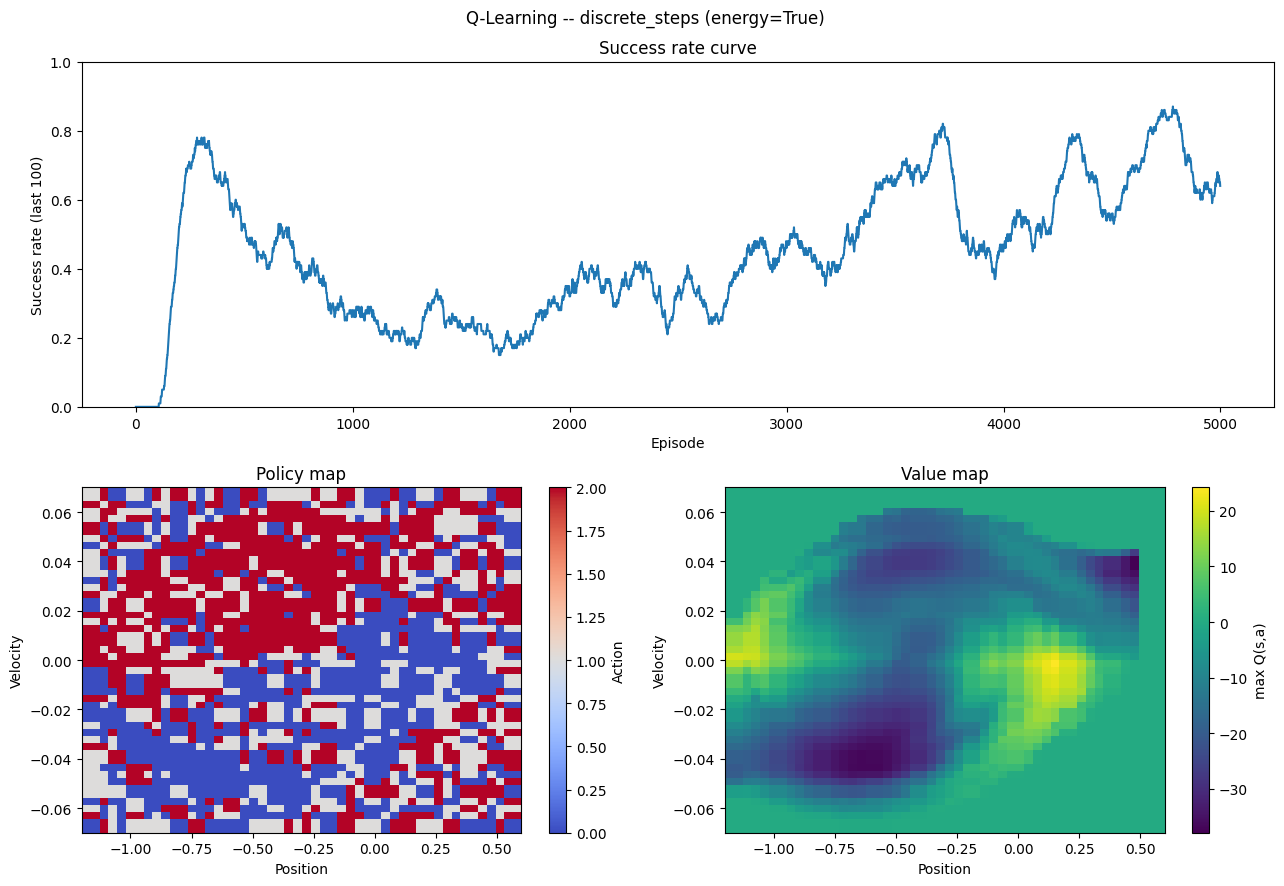

In [17]:
ql_data = pd.read_csv(f"../runs/qlearning_discrete_steps/log.csv").to_dict("records")
ql_agent_plot = QLearningAgent.load(f"saves/qlearning_discrete_steps/agent.npz", ql_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ql_data, ax=ax_top)
plots.policy_map(ql_agent_plot, ql_eval_env, ax=ax_bl)
plots.value_map(ql_agent_plot, ql_eval_env, ax=ax_br)
fig.suptitle(f"Q-Learning -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


In [ ]:
render_env = make_env(D_VARIANT, render_mode="human")
ql_agent_vis = QLearningAgent.load(f"runs/{ql_run}/agent.npz", render_env)

obs, _ = render_env.reset()
done = False
while not done:
    action = ql_agent_vis.choose_action(obs)
    obs, _, terminated, truncated, _ = render_env.step(action)
    done = terminated or truncated

render_env.close()

## DQN

### wawawawa awawawaw aw aawaw

In [18]:
dqn_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=GOAL_BONUS,
)
dqn_eval_env = make_env(D_VARIANT, seed=SEED + 100)

dqn_agent = DQNAgent(
    dqn_env,
    lr=1e-3,
    gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000,
    batch_size=100,
    warmup=2500,
    target_update=500,
    hidden=64,
    seed=SEED,
)


In [ ]:
dqn_run = f"dqn_{D_VARIANT}"
log_run(dqn_run, "DQNAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING,
                    "goal_bonus": GOAL_BONUS},
        agent_config=dqn_agent.get_config())
dqn_logger = trainer.run(dqn_env, dqn_agent, episodes=600, run_name=dqn_run)

Episode 0: reward=-197.3, steps=200, true_obj=200.0, success=False
Episode 100: reward=-176.4, steps=200, true_obj=200.0, success=False
Episode 200: reward=-186.7, steps=200, true_obj=200.0, success=False
Episode 300: reward=-137.2, steps=152, true_obj=152.0, success=True
Episode 400: reward=-202.6, steps=199, true_obj=199.0, success=True
Episode 500: reward=-164.0, steps=174, true_obj=174.0, success=True


In [21]:
dqn_agent.save(f"runs/{dqn_run}/agent.npz")

In [18]:
dqn_results = evaluator.evaluate(dqn_eval_env, dqn_agent, n=50, run_name=dqn_run)


Eval over 50 episodes: true_obj=101.62 +/- 19.33, success_rate=0.98, shaped_reward=-101.6


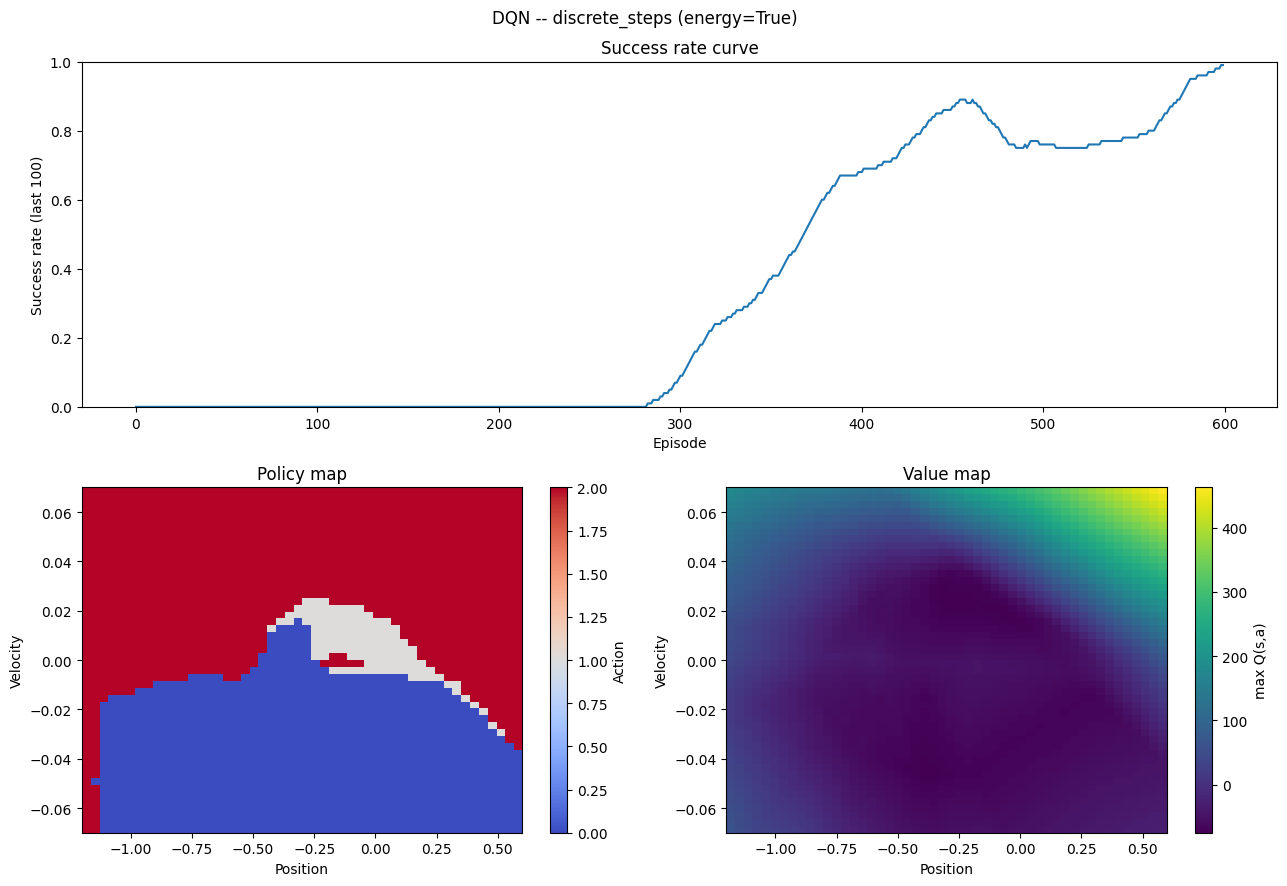

In [20]:
dqn_data = pd.read_csv(f"../runs/dqn_discrete_steps/log.csv").to_dict("records")
dqn_agent_plot = DQNAgent.load(f"saves/dqn_discrete_steps/agent.npz", dqn_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(dqn_data, ax=ax_top)
plots.policy_map(dqn_agent_plot, dqn_eval_env, ax=ax_bl)
plots.value_map(dqn_agent_plot, dqn_eval_env, ax=ax_br)
fig.suptitle(f"DQN -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


In [ ]:
render_env = make_env(D_VARIANT, render_mode="human")
dqn_agent_vis = DQNAgent.load(f"saves/dqn_{D_VARIANT}/agent.npz", render_env)

obs, _ = render_env.reset()
done = False
while not done:
    action = dqn_agent_vis.choose_action(obs)
    obs, _, terminated, truncated, _ = render_env.step(action)
    done = terminated or truncated

render_env.close()

In [ ]:
from gymnasium.wrappers import RecordVideo

render_env = make_env(D_VARIANT, render_mode="rgb_array")
render_env = RecordVideo(render_env, video_folder=f"saves/dqn_{D_VARIANT}/video", episode_trigger=lambda e: True)
dqn_agent_vis = DQNAgent.load(f"saves/dqn_{D_VARIANT}/agent.npz", render_env)

obs, _ = render_env.reset()
done = False
while not done:
    action = dqn_agent_vis.choose_action(obs)
    obs, _, terminated, truncated, _ = render_env.step(action)
    done = terminated or truncated

render_env.close()


c:\Users\rbelt\Desktop\previous-desktop\things\projects\uni\rl\rlvenv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\rbelt\Desktop\previous-desktop\things\projects\uni\rl\finalGroupAssignment\mountain_car\notebooks\saves\dqn_discrete_steps\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\rbelt\Desktop\previous-desktop\things\projects\uni\rl\rlvenv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## SAC

### BLa bla bla bla ablaablablab

In [23]:
sac_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=GOAL_BONUS,
)
sac_eval_env = make_env(C_VARIANT, seed=SEED + 100)

sac_agent = SACAgent(
    sac_env,
    lr=3e-4,
    gamma=0.99,
    buffer_size=100_000,
    batch_size=256,
    warmup=1000,
    seed=SEED,
)


In [14]:
sac_run = f"sac_{C_VARIANT}"
log_run(sac_run, "SACAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING,
                    "goal_bonus": GOAL_BONUS},
        agent_config=sac_agent.get_config())
sac_logger = trainer.run(sac_env, sac_agent, episodes=200, run_name=sac_run)
sac_agent.save(f"saves/{sac_run}/agent")

Episode 0: reward=50.9, steps=70, true_obj=70.0, success=True
Episode 100: reward=59.4, steps=73, true_obj=73.0, success=True


In [15]:
sac_results = evaluator.evaluate(sac_eval_env, sac_agent, n=50, run_name=sac_run)

Eval over 50 episodes: true_obj=70.56 +/- 0.96, success_rate=1.00, shaped_reward=23.5


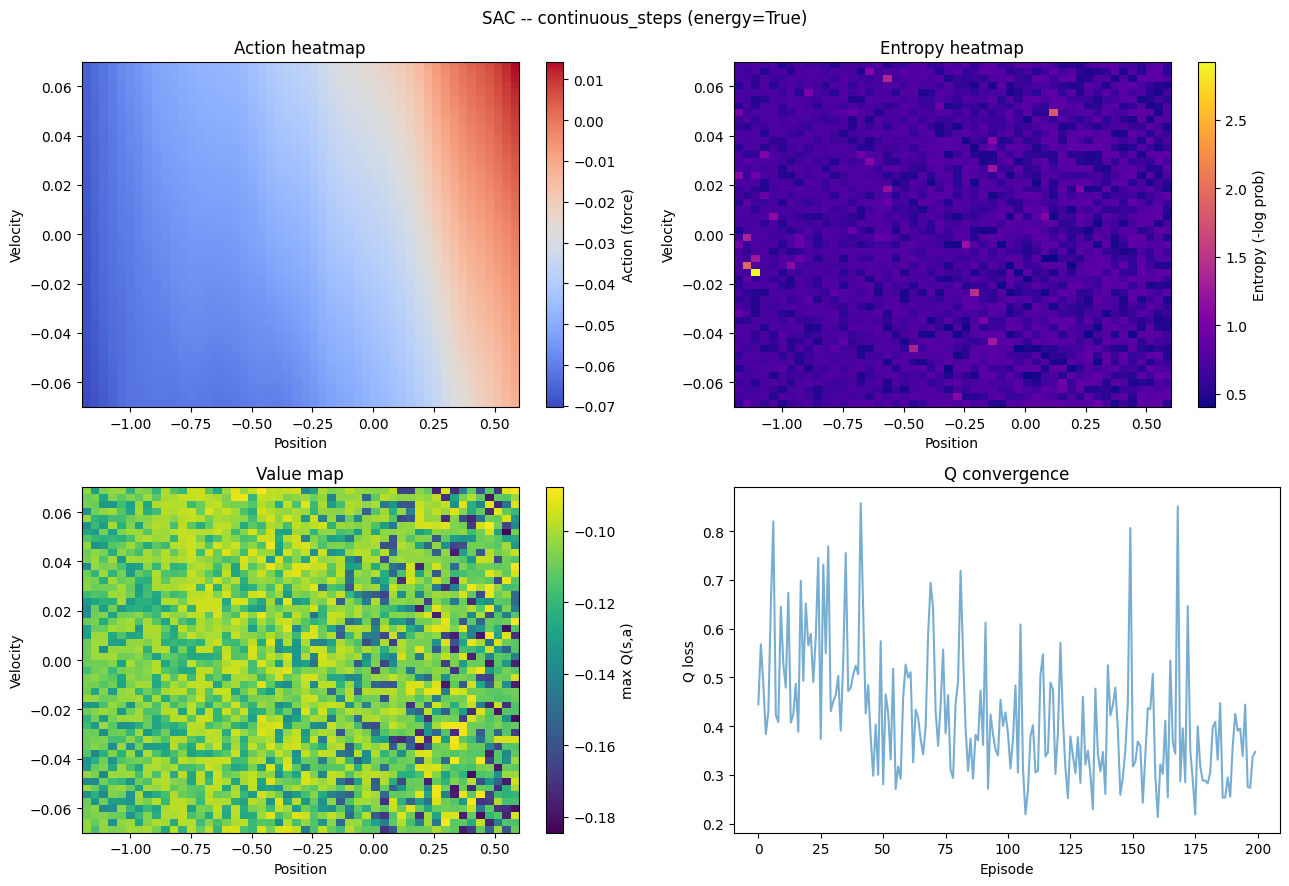

In [27]:
sac_data = pd.read_csv(f"../runs/sac_continuous_steps/log.csv").to_dict("records")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plots.action_heatmap(sac_agent, sac_eval_env, ax=axes[0, 0])
plots.entropy_heatmap(sac_agent, sac_eval_env, ax=axes[0, 1])
plots.value_map(sac_agent, sac_eval_env, ax=axes[1, 0])
plots.q_convergence(sac_data, ax=axes[1, 1])
fig.suptitle(f"SAC -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


In [37]:
from gymnasium.wrappers import RecordVideo

render_env = make_env("continuous_steps", render_mode="rgb_array")
render_env = RecordVideo(render_env, video_folder="saves/sac_continuous_steps/video", episode_trigger=lambda e: True)

obs, _ = render_env.reset()
done = False
while not done:
    action, _ = sac_agent.model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = render_env.step(action)
    done = terminated or truncated

render_env.close()
